## Thông tin nhóm
# ĐỀ TÀI 8: PHÁT HIỆN BỆNH PHỔI

**Nhóm:** [Tên nhóm 3-4 người]

**Thành viên:** Võ Hoàng Kim Ngân, Nhan Gia Huy

**GVHD:** Bùi Tiến Đức

**Thư viện:** Scikit-learn, Pandas, Numpy, PyTorch, Keras

## CELL 1 — IMPORT THƯ VIỆN (DUY NHẤT)

In [1]:
# CELL 1 — IMPORT THƯ VIỆN & CÀI ĐẶT (CHỈ CHẠY 1 LẦN)

import warnings
warnings.filterwarnings("ignore")

# ────────────────────────────────────────────────────────────────
# Import cơ bản
import os
import shutil
import glob
import numpy as np
from tqdm import tqdm
from pathlib import Path

# Hình ảnh & biểu đồ
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# Scikit-learn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# GPU config
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU sẵn sàng")
else:
    print("Chạy trên CPU")

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")

# Cài đặt thêm (nếu cần timm, xgboost, ... thì thêm sau)
print("Cài đặt một số gói bổ sung nếu cần...")
!pip install -q kagglehub timm

import kagglehub

print("\nHoàn tất Cell 1 – Thư viện sẵn sàng")

Chạy trên CPU
TensorFlow: 2.19.0 | NumPy: 2.0.2
Cài đặt một số gói bổ sung nếu cần...

Hoàn tất Cell 1 – Thư viện sẵn sàng


##Cell 1.5 - Set environment variable KAGGLE_API_TOKEN

In [2]:
# CELL 1.5 — KAGGLE API TOKEN (AN TOÀN)

from google.colab import userdata

KAGGLE_SECRET_NAME = "KAGGLE_API_TOKEN"   # ← Đổi tên secret nếu bạn đặt khác

try:
    kaggle_token = userdata.get(KAGGLE_SECRET_NAME)
    if not kaggle_token:
        raise ValueError("Secret rỗng")
except Exception as e:
    print("Không tìm thấy secret → dùng fallback (không khuyến khích)")
    kaggle_token = ""   # ← THAY BẰNG TOKEN CỦA BẠN NẾU CẦN (chỉ test)

os.environ['KAGGLE_USERNAME'] = "your_username"          # thay bằng username Kaggle của bạn
os.environ['KAGGLE_KEY'] = kaggle_token

# Kiểm tra nhanh
try:
    !kaggle datasets list -m --sort-by 'hottest' --max-size 1
    print("Kaggle API hoạt động bình thường")
except Exception as e:
    print("Lỗi Kaggle API:", str(e))
    print("→ Kiểm tra lại secret hoặc regenerate token trên Kaggle")

Không tìm thấy secret → dùng fallback (không khuyến khích)
ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
jamesb7/fuel-prices-uk                                           fuel-prices-uk                                         8860757  2026-03-29 23:30:07.940000             88          7                1  
sadiqguru/s-and-p-500-stock-data-along-with-financials-and-news  S&P 500 stock data along with financials and news     79140162  2026-03-27 18:44:47.867000            144          7                1  
mohankrishnathalla/predict-customer-churn-submission-dataset     Predict Customer Churn - Submission Dataset           72901164  2026-03-

##Cell 1.7 - Download dataset weights U-Net

In [3]:
# CELL 1.7 — TẢI WEIGHTS U-NET LUNG SEGMENTATION

from pathlib import Path

DATASET_SLUG = "farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays"
TARGET_DIR = Path("/content/unet_weights")
WEIGHTS_FILE = "cxr_reg_weights.best.hdf5"

if TARGET_DIR.exists() and (TARGET_DIR / WEIGHTS_FILE).exists():
    print(f"Đã có weights → skip tải: {TARGET_DIR / WEIGHTS_FILE}")
else:
    print(f"Đang tải dataset: {DATASET_SLUG}")
    !kaggle datasets download -d {DATASET_SLUG} -p {TARGET_DIR} --unzip --force
    print("Download & unzip xong")

weights_path = TARGET_DIR / WEIGHTS_FILE
if weights_path.exists():
    print(f"Found weights: {weights_path} ({weights_path.stat().st_size / (1024**2):.1f} MB)")
else:
    print("Không tìm thấy file weights mong đợi!")
    !ls -lh {TARGET_DIR}

Đang tải dataset: farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays
Dataset URL: https://www.kaggle.com/datasets/farhanhaikhan/unet-lung-segmentation-weights-for-chest-x-rays
License(s): CC0-1.0
100% 27.3M/27.3M [00:00<00:00, 113MB/s] 

Download & unzip xong
Found weights: /content/unet_weights/cxr_reg_weights.best.hdf5 (29.7 MB)


## CELL 2 — TẢI DATASET VÀ CHUẨN BỊ THƯ MỤC

In [4]:
# CELL 2 — TẢI DATASET 4 LỚP

DATASET_SLUG = "jtiptj/chest-xray-pneumoniacovid19tuberculosis"
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

if TRAIN_DIR.exists() and TEST_DIR.exists() and any(TRAIN_DIR.iterdir()):
    print("Dataset đã tồn tại → skip tải")
else:
    print(f"Đang tải dataset: {DATASET_SLUG}")
    dataset_path = kagglehub.dataset_download(DATASET_SLUG)
    print(f"Dataset tải về: {dataset_path}")

    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)
    DATA_DIR.mkdir(exist_ok=True)

    shutil.copytree(Path(dataset_path) / "train", TRAIN_DIR, dirs_exist_ok=True)
    shutil.copytree(Path(dataset_path) / "test", TEST_DIR, dirs_exist_ok=True)
    print("Copy train/test xong")

# Thống kê nhanh
print("\nTHỐNG KÊ DATASET")
for split, dir_path in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    print(f"\n{split.upper()}:")
    total = 0
    for cls in sorted(dir_path.iterdir()):
        if cls.is_dir():
            cnt = len(list(cls.glob("*.*")))
            print(f"  {cls.name:12} : {cnt:5d} ảnh")
            total += cnt
    print(f"  Tổng: {total} ảnh")

Đang tải dataset: jtiptj/chest-xray-pneumoniacovid19tuberculosis
Using Colab cache for faster access to the 'chest-xray-pneumoniacovid19tuberculosis' dataset.
Dataset tải về: /kaggle/input/chest-xray-pneumoniacovid19tuberculosis
Copy train/test xong

THỐNG KÊ DATASET

TRAIN:
  COVID19      :   460 ảnh
  NORMAL       :  1341 ảnh
  PNEUMONIA    :  3875 ảnh
  TURBERCULOSIS :   650 ảnh
  Tổng: 6326 ảnh

TEST:
  COVID19      :   106 ảnh
  NORMAL       :   234 ảnh
  PNEUMONIA    :   390 ảnh
  TURBERCULOSIS :    41 ảnh
  Tổng: 771 ảnh


## CELL 2.2 — TẢI U-NET PRE-TRAINED + TẠO MASKED DATASET

In [5]:
# CELL 2.5 — U-NET LUNG SEGMENTATION (tạo data_masked)

MASKED_DIR = Path('data_masked')
ORIGINAL_DIR = Path('data')

if MASKED_DIR.exists():
    print("Xóa data_masked cũ...")
    shutil.rmtree(MASKED_DIR)
MASKED_DIR.mkdir(exist_ok=True)

# ── Xây U-Net ────────────────────────────────────────────────────────
def build_unet(input_size=(256, 256, 1)):
    inputs = Input(input_size)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs); c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2,2))(c1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1); c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2,2))(c2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2); c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2,2))(c3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3); c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)
    d4 = Dropout(0.5)(c4); p4 = MaxPooling2D((2,2))(d4)
    c5 = Conv2D(512, 3, activation='relu', padding='same')(p4); c5 = Conv2D(512, 3, activation='relu', padding='same')(c5)
    d5 = Dropout(0.5)(c5)

    u6 = Conv2DTranspose(256, 2, strides=(2,2), padding='same')(d5)
    m6 = concatenate([d4, u6]); c6 = Conv2D(256, 3, activation='relu', padding='same')(m6); c6 = Conv2D(256, 3, activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(128, 2, strides=(2,2), padding='same')(c6)
    m7 = concatenate([c3, u7]); c7 = Conv2D(128, 3, activation='relu', padding='same')(m7); c7 = Conv2D(128, 3, activation='relu', padding='same')(c7)

    u8 = Conv2DTranspose(64, 2, strides=(2,2), padding='same')(c7)
    m8 = concatenate([c2, u8]); c8 = Conv2D(64, 3, activation='relu', padding='same')(m8); c8 = Conv2D(64, 3, activation='relu', padding='same')(c8)

    u9 = Conv2DTranspose(32, 2, strides=(2,2), padding='same')(c8)
    m9 = concatenate([c1, u9]); c9 = Conv2D(32, 3, activation='relu', padding='same')(m9); c9 = Conv2D(32, 3, activation='relu', padding='same')(c9)
    outputs = Conv2D(1, 1, activation='sigmoid')(c9)

    return Model(inputs, outputs)

segment_model = build_unet()
segment_model.load_weights('/content/unet_weights/cxr_reg_weights.best.hdf5')
print("U-Net weights loaded.")

# ── Hàm mask ─────────────────────────────────────────────────────────
def apply_lung_mask(img_path):
    try:
        gray = Image.open(img_path).convert('L').resize((256,256))
        arr = np.array(gray)[None,...,None] / 255.0
        mask = segment_model.predict(arr, verbose=0)[0]
        mask = (mask > 0.3).astype(np.float32)

        mask_r = tf.image.resize(mask, (224,224)).numpy()
        mask_r = np.repeat(mask_r, 3, -1)

        orig = Image.open(img_path).convert('RGB').resize((224,224))
        orig_arr = np.array(orig) / 255.0
        masked = orig_arr * mask_r
        return (masked * 255).astype(np.uint8)
    except:
        return None

# ── Chạy segmentation ────────────────────────────────────────────────
for split in ['train', 'test']:
    src = ORIGINAL_DIR / split
    dst = MASKED_DIR / split
    if not src.exists(): continue
    dst.mkdir(parents=True, exist_ok=True)

    for cls_dir in src.iterdir():
        if not cls_dir.is_dir(): continue
        dst_cls = dst / cls_dir.name
        dst_cls.mkdir(exist_ok=True)

        images = sum([list(cls_dir.glob(pat)) for pat in ['*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG']], [])
        print(f"{split}/{cls_dir.name}: {len(images)} ảnh")

        for p in tqdm(images, desc=cls_dir.name):
            masked = apply_lung_mask(p)
            if masked is not None:
                Image.fromarray(masked).save(dst_cls / p.name)

print("\nHoàn tất tạo data_masked!")

U-Net weights loaded.
train/NORMAL: 1341 ảnh


NORMAL: 100%|██████████| 1341/1341 [17:44<00:00,  1.26it/s]


train/TURBERCULOSIS: 650 ảnh


TURBERCULOSIS: 100%|██████████| 650/650 [07:50<00:00,  1.38it/s]


train/COVID19: 460 ảnh


...

test/COVID19: 106 ảnh


COVID19: 100%|██████████| 106/106 [01:27<00:00,  1.21it/s]


test/PNEUMONIA: 390 ảnh


PNEUMONIA: 100%|██████████| 390/390 [04:39<00:00,  1.40it/s]


Hoàn tất tạo data_masked!


##Cell 2.3 - Thư mục bổ sung Data

In [6]:
#Cell 2.3 - Thư mục bổ sung Data
import os
from pathlib import Path
import shutil

# Tạo thư mục bổ sung
supplement_dir = Path('supplement_data')
supplement_dir.mkdir(exist_ok=True)

# Tạo thư mục cho từng lớp trong supplement
for cls in ['NORMAL', 'TUBERCULOSIS']:
    (supplement_dir / cls).mkdir(exist_ok=True)

# Đảm bảo thư mục đích trong data_masked/train tồn tại
masked_train = Path('data_masked/train')
for cls in ['NORMAL', 'TUBERCULOSIS']:
    (masked_train / cls).mkdir(exist_ok=True)

print("✅ Đã tạo các thư mục bổ sung và đích.")
print("Cấu trúc hiện tại:")
for cls in ['NORMAL', 'TUBERCULOSIS']:
    cnt = len(list((masked_train / cls).glob('*.*')))
    print(f"  {cls:12} : {cnt} ảnh")

✅ Đã tạo các thư mục bổ sung và đích.
Cấu trúc hiện tại:
  NORMAL       : 1341 ảnh
  TUBERCULOSIS : 0 ảnh


##Cell 2.4 - Tải Dataset bổ sung

In [7]:
##Cell 2.4 - Tải Dataset bổ sung
# Tải dataset Tuberculosis (Lao phổi)
print("Đang tải Tuberculosis dataset...")
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p supplement_data --unzip -q

# Tải dataset Chest X-ray Pneumonia (để lấy thêm NORMAL)
print("Đang tải Chest X-ray Pneumonia dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p supplement_data --unzip -q

print("✅ Hoàn tất tải dataset bổ sung!")

Đang tải Tuberculosis dataset...
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
Đang tải Chest X-ray Pneumonia dataset...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
✅ Hoàn tất tải dataset bổ sung!


##Cell 2.5 - Lấy ảnh bổ sung để train/test

In [8]:
##Cell 2.5 - Lấy ảnh bổ sung để train/test
from pathlib import Path
import shutil
import glob

supplement_path = Path('supplement_data')
masked_train = Path('data_masked/train')

print("=== Bắt đầu copy dữ liệu bổ sung ===")

# 1. Copy Tuberculosis
tb_source_dirs = [
    supplement_path / 'TB_Chest_Radiography_Database' / 'Tuberculosis',
    supplement_path / 'TB Chest X-ray' / 'TB'
]

tb_files = []
for src_dir in tb_source_dirs:
    if src_dir.exists():
        tb_files.extend(list(src_dir.glob('*.png')) + list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.jpeg')))

tb_files = tb_files[:450]   # giới hạn 450 ảnh

for f in tb_files:
    dest_path = masked_train / 'TUBERCULOSIS' / f.name
    shutil.copy(f, dest_path)

print(f"✅ Đã copy {len(tb_files)} ảnh vào TUBERCULOSIS")

# 2. Copy NORMAL
normal_source = supplement_path / 'chest_xray' / 'train' / 'NORMAL'
if normal_source.exists():
    normal_files = list(normal_source.glob('*.jpeg')) + list(normal_source.glob('*.jpg'))
    normal_files = normal_files[:550]   # lấy khoảng 550 ảnh

    for f in normal_files:
        dest_path = masked_train / 'NORMAL' / f.name
        shutil.copy(f, dest_path)

    print(f"✅ Đã copy {len(normal_files)} ảnh vào NORMAL")
else:
    print("⚠️ Không tìm thấy thư mục NORMAL từ chest-xray-pneumonia")

# Kiểm tra sau khi copy
print("\n=== Kiểm tra sau khi bổ sung ===")
for cls in ['NORMAL', 'TUBERCULOSIS']:
    cnt = len(list((masked_train / cls).glob('*.*')))
    print(f"{cls:12} : {cnt} ảnh")

=== Bắt đầu copy dữ liệu bổ sung ===
✅ Đã copy 450 ảnh vào TUBERCULOSIS
✅ Đã copy 550 ảnh vào NORMAL

=== Kiểm tra sau khi bổ sung ===
NORMAL       : 1341 ảnh
TUBERCULOSIS : 450 ảnh


##Cell 2.6 – Kiểm tra số lượng trước / sau segmentation

In [9]:
# CELL 2.6 — KIỂM TRA SỐ LƯỢNG ẢNH TRƯỚC / SAU SEGMENTATION

def count_images(root_dir):
    stats = {}
    total = 0
    if not os.path.exists(root_dir):
        return {}, 0
    for cls in sorted(os.listdir(root_dir)):
        p = os.path.join(root_dir, cls)
        if os.path.isdir(p):
            cnt = len([f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg'))])
            stats[cls] = cnt
            total += cnt
    return stats, total

print("=== ORIGINAL data/train ===")
orig_stats, orig_total = count_images('data/train')
for k, v in orig_stats.items():
    print(f"{k:15} : {v:6d}")
print(f"Tổng: {orig_total}\n")

print("=== MASKED data_masked/train ===")
mask_stats, mask_total = count_images('data_masked/train')
for k, v in mask_stats.items():
    print(f"{k:15} : {v:6d}")
print(f"Tổng: {mask_total}\n")

if orig_total == mask_total and mask_total > 0 and all(v > 0 for v in mask_stats.values()):
    print("→ Segmentation thành công: số lượng khớp & không lớp nào bị thiếu!")
else:
    print("→ Cảnh báo: Có sự khác biệt hoặc một số lớp bị thiếu → kiểm tra lại!")

=== ORIGINAL data/train ===
COVID19         :    460
NORMAL          :   1341
PNEUMONIA       :   3875
TURBERCULOSIS   :    650
Tổng: 6326

=== MASKED data_masked/train ===
COVID19         :    460
NORMAL          :   1341
PNEUMONIA       :   3875
TUBERCULOSIS    :    450
TURBERCULOSIS   :    650
Tổng: 6776

→ Cảnh báo: Có sự khác biệt hoặc một số lớp bị thiếu → kiểm tra lại!


##CELL 2.7 — TIỀN XỬ LÝ DỮ LIỆU

In [10]:
# CELL 2.7 — TIỀN XỬ LÝ DỮ LIỆU (ĐÃ SỬA GLOB - CHẠY LẠI SAU KHI CÓ data_masked)

import os
import glob
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_dir = 'data_masked/train'

print("=== CELL 2.7: KIỂM TRA VÀ TÍNH CLASS WEIGHT ===")

if not os.path.exists(train_dir):
    print("❌ Chưa có thư mục data_masked/train!")
else:
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    print(f"Các lớp tìm thấy: {classes}\n")

    y_train = []
    file_counts = {}

    for i, cls in enumerate(classes):
        # Pattern glob mạnh hơn - bắt tất cả jpg, jpeg, png (không phân biệt hoa thường)
        patterns = [
            os.path.join(train_dir, cls, '*.jpg'),
            os.path.join(train_dir, cls, '*.jpeg'),
            os.path.join(train_dir, cls, '*.png'),
            os.path.join(train_dir, cls, '*.JPG'),
            os.path.join(train_dir, cls, '*.JPEG'),
            os.path.join(train_dir, cls, '*.PNG')
        ]

        files = []
        for pat in patterns:
            files.extend(glob.glob(pat))

        count = len(files)
        file_counts[cls] = count
        y_train.extend([i] * count)

        print(f"{cls:12} : {count:6d} ảnh")

    print(f"\nTổng ảnh train: {len(y_train)}")

    if len(y_train) > 0 and len(set(y_train)) == 4:
        class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        # Boost nhẹ cho lớp ít ảnh
        class_weight_dict = {i: w * 1.3 for i, w in enumerate(class_weights)}

        print("\n✅ Class weights thực tế (boost x1.3 cho lớp thiểu số):")
        for i, cls in enumerate(classes):
            print(f"  {cls:12} (index {i}): {class_weight_dict[i]:.3f}")
    else:
        print("\n⚠️  Cảnh báo: Không đủ 4 lớp hoặc không có ảnh → kiểm tra lại Cell 2.5")

=== CELL 2.7: KIỂM TRA VÀ TÍNH CLASS WEIGHT ===
Các lớp tìm thấy: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TUBERCULOSIS', 'TURBERCULOSIS']

COVID19      :    460 ảnh
NORMAL       :   1341 ảnh
PNEUMONIA    :   3875 ảnh
TUBERCULOSIS :    450 ảnh
TURBERCULOSIS :    650 ảnh

Tổng ảnh train: 6776

⚠️  Cảnh báo: Không đủ 4 lớp hoặc không có ảnh → kiểm tra lại Cell 2.5


##CELL DEBUG: Kiểm tra và sửa số lớp trong data_masked/train

In [11]:
from pathlib import Path
import shutil

train_dir = Path('data_masked/train')

source_dir = train_dir / 'TURBERCULOSIS'   # thư mục sai chính tả
target_dir = train_dir / 'TUBERCULOSIS'   # thư mục đúng

if source_dir.exists():
    print(f"Đang dồn ảnh từ '{source_dir.name}' sang '{target_dir.name}'...")

    # Copy tất cả file từ thư mục sai sang thư mục đúng
    for file in source_dir.iterdir():
        if file.is_file():
            shutil.copy2(file, target_dir / file.name)

    num_moved = len(list(source_dir.iterdir()))
    print(f"✅ Đã chuyển {num_moved} ảnh từ TURBERCULOSIS sang TUBERCULOSIS")

    # Xóa thư mục thừa
    shutil.rmtree(source_dir)
    print(f"✅ Đã xóa thư mục thừa: {source_dir.name}")
else:
    print("Không tìm thấy thư mục TURBERCULOSIS")

# Kiểm tra lại
print("\nKiểm tra sau khi dồn:")
for cls in sorted([d.name for d in train_dir.iterdir() if d.is_dir()]):
    count = len(list((train_dir / cls).iterdir()))
    print(f"  {cls:15} : {count} ảnh")

Đang dồn ảnh từ 'TURBERCULOSIS' sang 'TUBERCULOSIS'...
✅ Đã chuyển 650 ảnh từ TURBERCULOSIS sang TUBERCULOSIS
✅ Đã xóa thư mục thừa: TURBERCULOSIS

Kiểm tra sau khi dồn:
  COVID19         : 460 ảnh
  NORMAL          : 1341 ảnh
  PNEUMONIA       : 3875 ảnh
  TUBERCULOSIS    : 677 ảnh


##Cell kiểm tra 1: Xem thư mục data_masked/train có những lớp nào?

In [12]:
import os

masked_train = 'data_masked/train'

if not os.path.exists(masked_train):
    print("❌ Thư mục data_masked/train KHÔNG tồn tại!")
else:
    folders = [d for d in os.listdir(masked_train) if os.path.isdir(os.path.join(masked_train, d))]
    print("Các thư mục lớp hiện có trong data_masked/train:")
    print(folders if folders else "→ Rỗng hoàn toàn!")

    for folder in folders:
        path = os.path.join(masked_train, folder)
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"  {folder:15} → {count} ảnh")

Các thư mục lớp hiện có trong data_masked/train:
['NORMAL', 'COVID19', 'PNEUMONIA', 'TUBERCULOSIS']
  NORMAL          → 1341 ảnh
  COVID19         → 460 ảnh
  PNEUMONIA       → 3875 ảnh
  TUBERCULOSIS    → 677 ảnh


##Cell kiểm tra 2: So sánh số lượng gốc vs masked

In [13]:
import os

def quick_count(base):
    if not os.path.exists(base): return "Không tồn tại"
    return {d: len(os.listdir(os.path.join(base, d))) for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))}

print("data/train:", quick_count('data/train'))
print("data_masked/train:", quick_count('data_masked/train'))

data/train: {'NORMAL': 1341, 'TURBERCULOSIS': 650, 'COVID19': 460, 'PNEUMONIA': 3875}
data_masked/train: {'NORMAL': 1341, 'COVID19': 460, 'PNEUMONIA': 3875, 'TUBERCULOSIS': 677}


##Cell kiểm tra 3: Xem tên lớp thật sự trong data gốc (để phát hiện lỗi typo)

In [14]:
import os

print("Các thư mục trong data/train:")
print(os.listdir('data/train') if os.path.exists('data/train') else "Không tồn tại")

Các thư mục trong data/train:
['NORMAL', 'TURBERCULOSIS', 'COVID19', 'PNEUMONIA']


##CELL 3 — TRAIN SWIN TRANSFORMER + MASKED IMAGES

In [15]:
# CELL 3.5 — HYBRID MODEL: MobileNetV2 Feature Extractor + ANN sâu

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ================== DATA GENERATORS ==================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.95, 1.05],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    'data_masked/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    'data_masked/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ================== CLASS WEIGHTS ==================
classes = np.unique(train_gen.classes)
class_weights_raw = compute_class_weight('balanced', classes=classes, y=train_gen.classes)

class_weight_dict = {
    0: class_weights_raw[0] * 2.2,   # COVID19
    1: class_weights_raw[1] * 3.5,   # NORMAL
    2: class_weights_raw[2] * 0.8,   # PNEUMONIA
    3: class_weights_raw[3] * 3.0    # TUBERCULOSIS
}

print("Class weights:")
for i, name in enumerate(train_gen.class_indices.keys()):
    print(f"  {name:12}: {class_weight_dict[i]:.3f}")

# ================== HYBRID MODEL (MobileNetV2 + ANN sâu) ==================
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Feature Extraction
x = base_model.output
x = GlobalAveragePooling2D()(x)

# ================== PHẦN ANN SÂU ==================
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.35)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint('best_hybrid_mobilenet_ann.keras', monitor='val_accuracy', save_best_only=True)
]

# ================== TRAIN ==================
print("\n=== Giai đoạn 1: Freeze base ===")
history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print("\n=== Giai đoạn 2: Fine-tune ===")
base_model.trainable = True
for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=test_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

# Đánh giá
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n🎯 Test Accuracy Hybrid Model: {test_acc*100:.2f}%")

model.save('lung_hybrid_mobilenet_ann_final.keras')
print("Model Hybrid đã được lưu!")

Found 6353 images belonging to 4 classes.
Found 771 images belonging to 4 classes.
Class weights:
  COVID19     : 7.596
  NORMAL      : 4.145
  PNEUMONIA   : 0.328
  TUBERCULOSIS: 7.038
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Giai đoạn 1: Freeze base ===
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.5907 - loss: 0.1773 - val_accuracy: 0.7990 - val_loss: 0.0494 - learning_rate: 5.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.7858 - loss: 0.0733 - val_accuracy: 0.7860 - val_loss: 0.0496 - learning_rate: 5.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8275 - loss: 0.0552 - val_accuracy: 0.7899 - val_loss: 0.0522 - learning_rate: 5.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.8605 - loss: 0.0449 - val_accuracy: 0.8573 - val_loss: 0.0300 - learning_rate: 5.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.8500 - loss: 0.0415 - val_accuracy: 

##CELL 3.5 — VISUALIZE & REPORT KẾT QUẢ

📊 ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET
🎯 Test Accuracy: 81.06%
   Test Loss:     0.0724

Confusion Matrix:


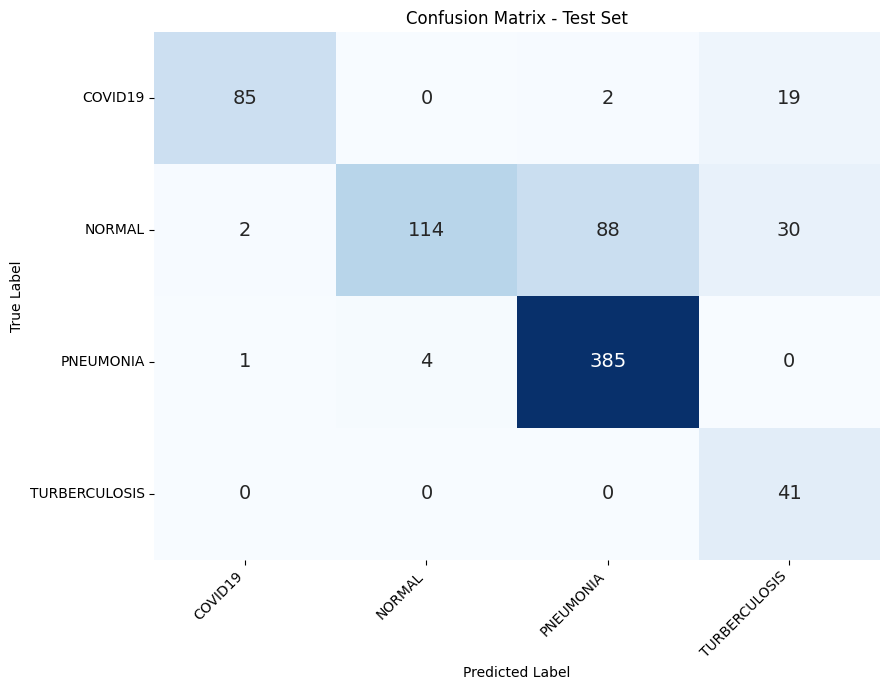


📈 Biểu đồ so sánh Accuracy - Precision - Recall - F1-score theo từng lớp


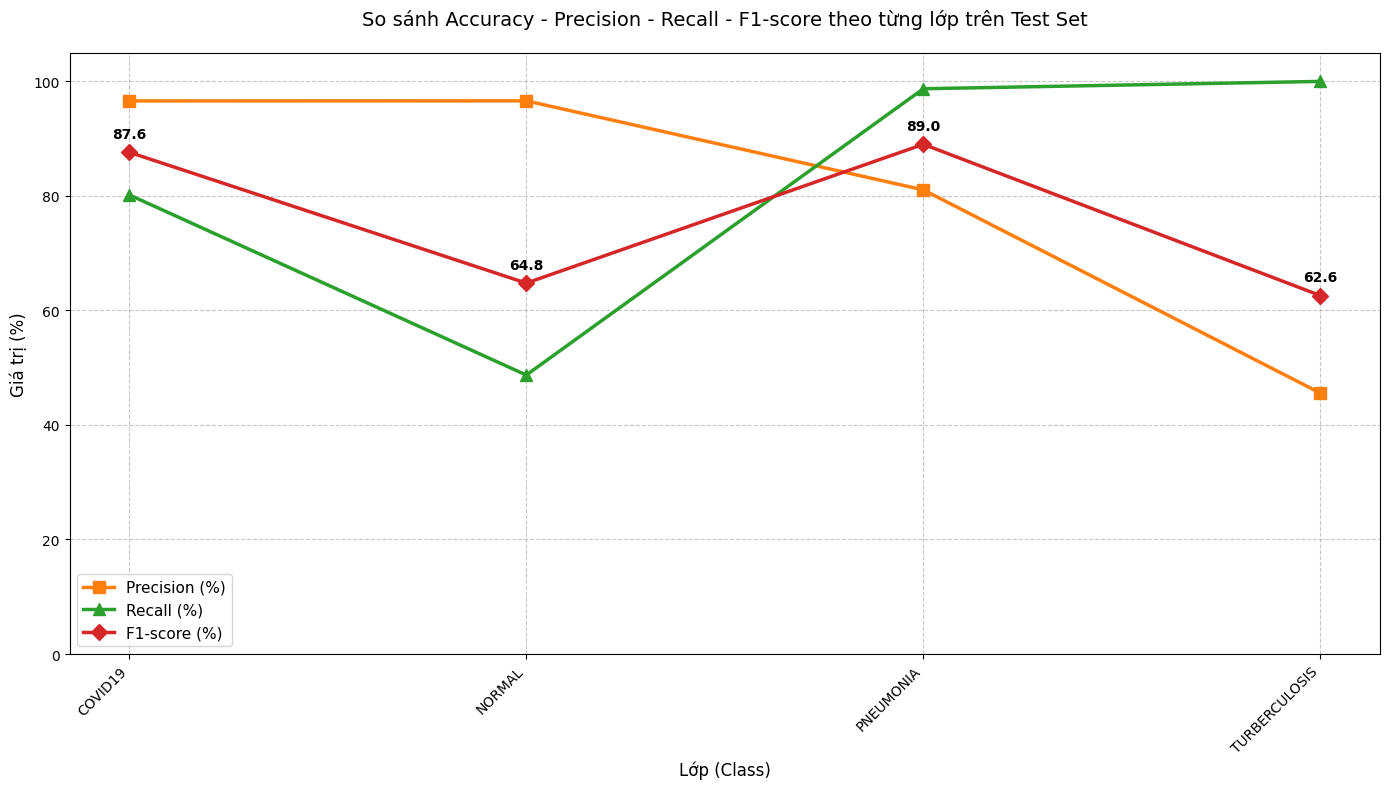


Classification Report (chi tiết từng lớp):
               precision  recall  f1-score  support
Class                                              
COVID19            0.966   0.802     0.876  106.000
NORMAL             0.966   0.487     0.648  234.000
PNEUMONIA          0.811   0.987     0.890  390.000
TURBERCULOSIS      0.456   1.000     0.626   41.000
accuracy           0.811   0.811     0.811    0.811
macro avg          0.800   0.819     0.760  771.000
weighted avg       0.860   0.811     0.801  771.000

Tóm tắt nhanh:
• Accuracy:          81.06%
• Macro Avg F1-score: 76.00%
• Weighted Avg F1:   80.06%


In [19]:
# CELL 3.5 — VISUALIZE & REPORT KẾT QUẢ

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

print("="*60)
print("📊 ĐÁNH GIÁ CUỐI CÙNG TRÊN TEST SET")
print("="*60)

# Sử dụng test_gen từ Cell 3.5
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"🎯 Test Accuracy: {test_acc*100:.2f}%")
print(f"   Test Loss:     {test_loss:.4f}")

# Dự đoán
y_pred = model.predict(test_gen, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(test_gen.class_indices.keys()),
            yticklabels=list(test_gen.class_indices.keys()),
            cbar=False, annot_kws={"size": 14})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# === BIỂU ĐỒ ĐƯỜNG MULTI-METRICS (Accuracy - Precision - Recall - F1) ===
print("\n📈 Biểu đồ so sánh Accuracy - Precision - Recall - F1-score theo từng lớp")

class_names = list(test_gen.class_indices.keys())
accuracy_per_class = []
precision_per_class = []
recall_per_class = []
f1_per_class = []

for i, class_name in enumerate(class_names):
    idx = (y_true == i)
    support = np.sum(idx)

    if support > 0:
        # Accuracy
        acc = np.mean(y_pred_classes[idx] == y_true[idx])

        # Precision, Recall, F1
        tp = np.sum((y_pred_classes == i) & (y_true == i))
        fp = np.sum((y_pred_classes == i) & (y_true != i))
        fn = np.sum((y_pred_classes != i) & (y_true == i))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    else:
        acc = precision = recall = f1 = 0.0

    accuracy_per_class.append(acc * 100)
    precision_per_class.append(precision * 100)
    recall_per_class.append(recall * 100)
    f1_per_class.append(f1 * 100)

# Vẽ biểu đồ multi-line
plt.figure(figsize=(14, 8))

x = np.arange(len(class_names))

plt.plot(x, precision_per_class, marker='s', linewidth=2.5, markersize=8, label='Precision (%)', color='#ff7f0e')
plt.plot(x, recall_per_class,    marker='^', linewidth=2.5, markersize=8, label='Recall (%)',    color='#2ca02c')
plt.plot(x, f1_per_class,        marker='D', linewidth=2.5, markersize=8, label='F1-score (%)',  color='#d62728')

# Hiển thị giá trị % trên các điểm (chỉ hiển thị F1 để tránh biểu đồ bị rối)
for i, f1 in enumerate(f1_per_class):
    plt.text(i, f1 + 2, f'{f1:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('So sánh Accuracy - Precision - Recall - F1-score theo từng lớp trên Test Set',
          fontsize=14, pad=20)
plt.xlabel('Lớp (Class)', fontsize=12)
plt.ylabel('Giá trị (%)', fontsize=12)
plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report (chi tiết từng lớp):")
report = classification_report(y_true, y_pred_classes,
                              target_names=list(test_gen.class_indices.keys()),
                              output_dict=True)

report_df = pd.DataFrame(report).transpose().round(3)
report_df.index.name = 'Class'
print(report_df)

# Tóm tắt
print("\nTóm tắt nhanh:")
print(f"• Accuracy:          {report['accuracy']*100:.2f}%")
print(f"• Macro Avg F1-score: {report['macro avg']['f1-score']*100:.2f}%")
print(f"• Weighted Avg F1:   {report['weighted avg']['f1-score']*100:.2f}%")

##Cell 3.6 - Grad-Cam

Grad-CAM sẵn sàng! Model hiện tại: functional_1

Test Grad-CAM trên ảnh mẫu từ test set:

→ Lớp thật: COVID19


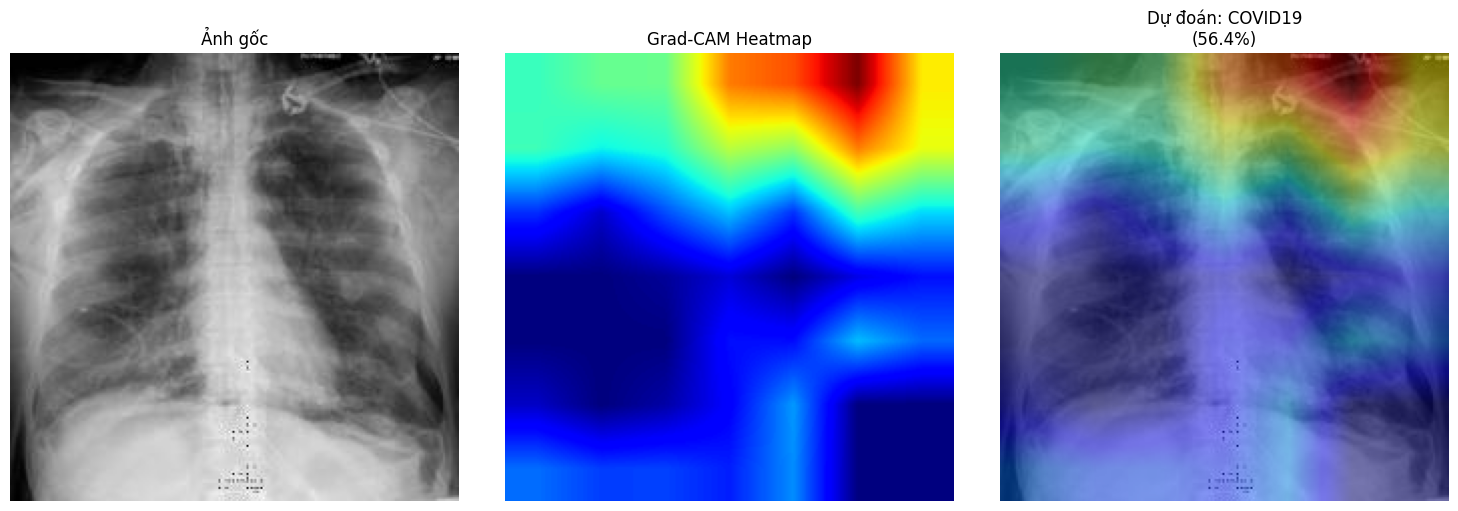


→ Lớp thật: NORMAL


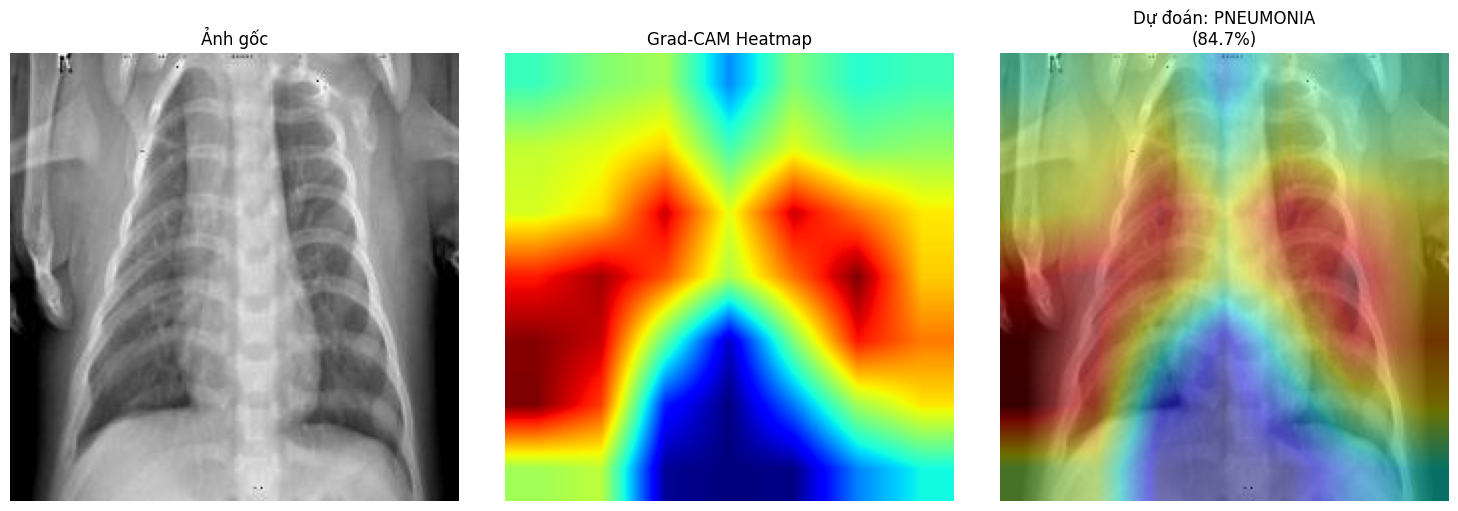


→ Lớp thật: PNEUMONIA


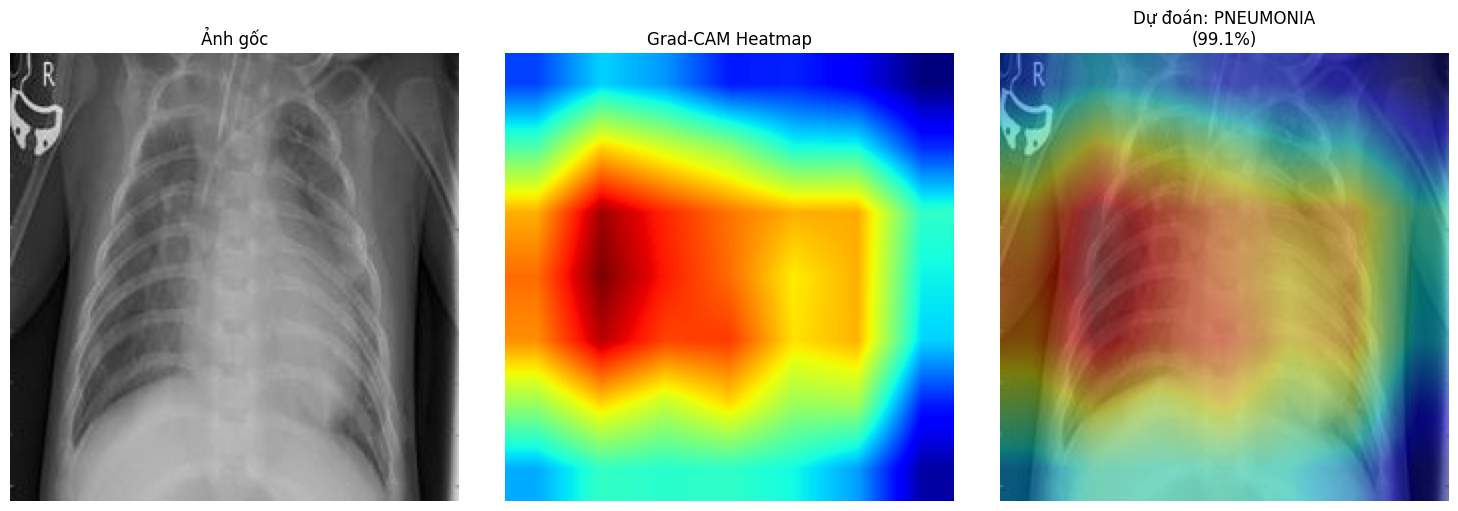


→ Lớp thật: TURBERCULOSIS


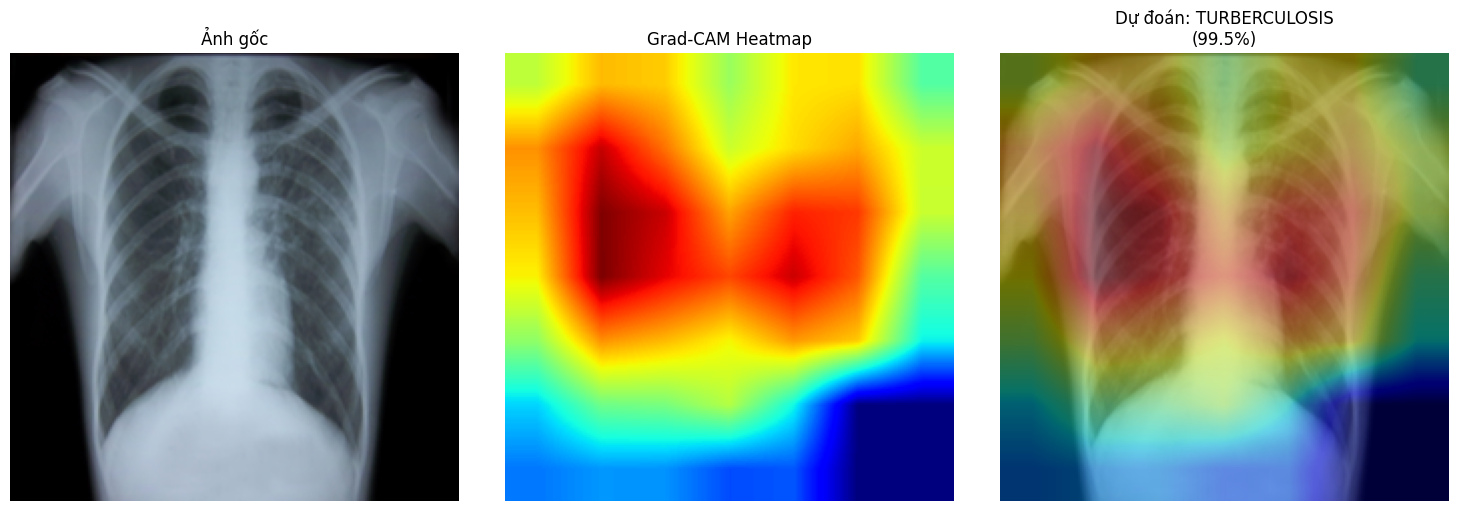


Nếu muốn test ảnh từ máy, hãy dùng phần upload bên dưới.


In [20]:
# CELL 3.6 — GRAD-CAM VISUALIZATION

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K
from PIL import Image
import glob
import os
from google.colab import files

# Hàm Grad-CAM
def get_gradcam_heatmap(model, img_array, class_idx, last_conv_layer_name='Conv_1'):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = K.mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = tf.nn.relu(heatmap)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()

def display_gradcam(img_path, model, last_conv_layer_name='Conv_1', alpha=0.45):
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = np.array(img) / 255.0
    img_array_exp = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array_exp, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class_name = list(test_gen.class_indices.keys())[pred_idx]
    confidence = preds[pred_idx] * 100

    heatmap = get_gradcam_heatmap(model, img_array_exp, pred_idx, last_conv_layer_name)

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Ảnh gốc")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.title(f"Dự đoán: {pred_class_name}\n({confidence:.1f}%)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Sử dụng model hiện tại
print("Grad-CAM sẵn sàng! Model hiện tại:", model.name if hasattr(model, 'name') else "Custom Model")

# Test trên một số ảnh mẫu từ test set
print("\nTest Grad-CAM trên ảnh mẫu từ test set:")
test_base = 'data_masked/test'

for class_name in list(test_gen.class_indices.keys()):
    try:
        class_path = os.path.join(test_base, class_name)
        sample_img = glob.glob(os.path.join(class_path, '*.*'))[0]
        print(f"\n→ Lớp thật: {class_name}")
        display_gradcam(sample_img, model, last_conv_layer_name='Conv_1', alpha=0.45)
    except Exception as e:
        print(f"   Không tìm thấy ảnh cho lớp {class_name} hoặc lỗi: {e}")

print("\nNếu muốn test ảnh từ máy, hãy dùng phần upload bên dưới.")

## CELL 4 - KIỂM TRA DỰ ĐOÁN THỰC TẾ (TEST BIAS + UPLOAD ẢNH TỪ MÁY)

✅ Đã load model: lung_hybrid_mobilenet_ann_final.keras
Các lớp: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']

=== Test trên ảnh mẫu từ data_masked/test ===


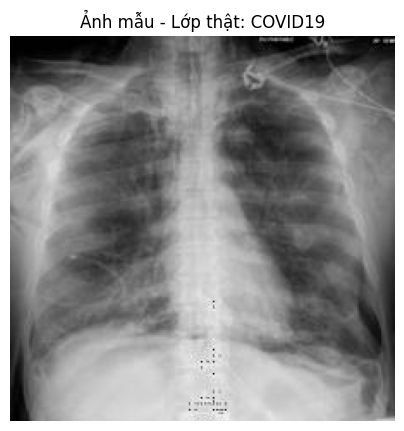

Dự đoán: COVID19 (56.35%)
Xác suất chi tiết:
   COVID19: 56.35%
   NORMAL: 7.05%
   PNEUMONIA: 16.86%
   TURBERCULOSIS: 19.74%
--------------------------------------------------


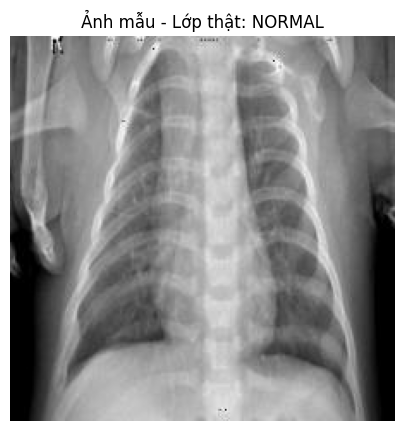

Dự đoán: PNEUMONIA (84.70%)
Xác suất chi tiết:
   COVID19: 0.00%
   NORMAL: 15.30%
   PNEUMONIA: 84.70%
   TURBERCULOSIS: 0.00%
--------------------------------------------------


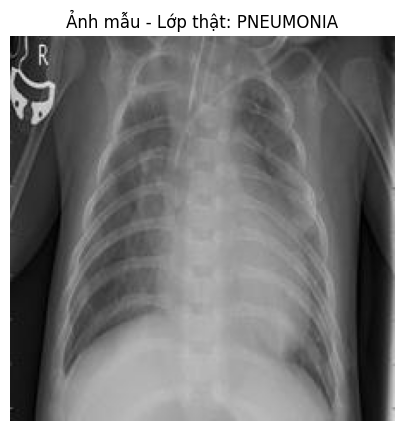

Dự đoán: PNEUMONIA (99.12%)
Xác suất chi tiết:
   COVID19: 0.06%
   NORMAL: 0.75%
   PNEUMONIA: 99.12%
   TURBERCULOSIS: 0.08%
--------------------------------------------------


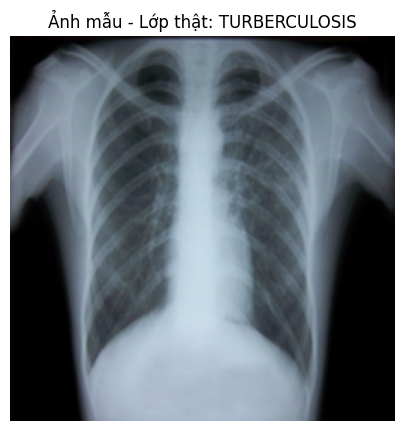

Dự đoán: TURBERCULOSIS (99.47%)
Xác suất chi tiết:
   COVID19: 0.52%
   NORMAL: 0.01%
   PNEUMONIA: 0.00%
   TURBERCULOSIS: 99.47%
--------------------------------------------------

=== Upload ảnh X-quang từ máy để test thực tế ===
Hãy upload ảnh Normal, COVID19, Viêm phổi, Lao phổi để kiểm tra


Saving download (1).jpg to download (1).jpg

Đang dự đoán: download (1).jpg


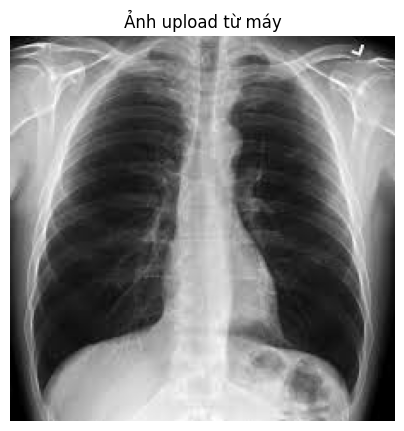

→ Dự đoán: TURBERCULOSIS (67.95%)
Xác suất chi tiết:
   COVID19: 31.99%
   NORMAL: 0.05%
   PNEUMONIA: 0.01%
   TURBERCULOSIS: 67.95%
------------------------------------------------------------


In [28]:
# CELL 4 — KIỂM TRA DỰ ĐOÁN THỰC TẾ & UPLOAD ẢNH TỪ MÁY

import os
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf

# Load model (nếu chưa load)
MODEL_PATH = 'lung_hybrid_mobilenet_ann_final.keras'   # thay tên nếu khác

if not os.path.exists(MODEL_PATH):
    MODEL_PATH = 'lung_hybrid_mobilenet_ann_final.keras'

model = tf.keras.models.load_model(MODEL_PATH)
print(f"✅ Đã load model: {MODEL_PATH}")

# Class names
class_names = list(test_gen.class_indices.keys())
print("Các lớp:", class_names)

# Phần 1: Test trên ảnh mẫu từ test set
print("\n=== Test trên ảnh mẫu từ data_masked/test ===")
test_base = 'data_masked/test'

for cls in class_names:
    try:
        sample_path = glob.glob(f"{test_base}/{cls}/*.*")[0]
        img = Image.open(sample_path).convert('RGB')
        plt.figure(figsize=(5,5))
        plt.imshow(img)
        plt.title(f"Ảnh mẫu - Lớp thật: {cls}")
        plt.axis('off')
        plt.show()

        img_resized = img.resize((224, 224))
        img_array = np.array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(pred)
        confidence = pred[pred_idx] * 100

        print(f"Dự đoán: {class_names[pred_idx]} ({confidence:.2f}%)")
        print("Xác suất chi tiết:")
        for i, name in enumerate(class_names):
            print(f"   {name}: {pred[i]*100:.2f}%")
        print("-" * 50)
    except:
        print(f"Không tìm thấy ảnh mẫu cho lớp {cls}")

# Phần 2: Upload ảnh từ máy để test
print("\n=== Upload ảnh X-quang từ máy để test thực tế ===")
print("Hãy upload ảnh Normal, COVID19, Viêm phổi, Lao phổi để kiểm tra")

uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nĐang dự đoán: {filename}")
    img = Image.open(filename).convert('RGB')
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title("Ảnh upload từ máy")
    plt.axis('off')
    plt.show()

    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred)
    confidence = pred[pred_idx] * 100

    print(f"→ Dự đoán: {class_names[pred_idx]} ({confidence:.2f}%)")
    print("Xác suất chi tiết:")
    for i, name in enumerate(class_names):
        print(f"   {name}: {pred[i]*100:.2f}%")
    print("-" * 60)

## CELL 5: HUGGING FACE LOGIN

In [29]:
# CELL 5 – LOGIN VÀO HUGGING FACE (chạy 1 lần duy nhất)

!pip install -q huggingface_hub

from huggingface_hub import login

# Chạy dòng này → sẽ hiện ô paste token
login()

In [30]:
from huggingface_hub import whoami
whoami()  # Nếu OK: in username và role (write)

{'type': 'user',
 'id': '6951289cfbddb08cb2422421',
 'name': 'Silver3424',
 'fullname': 'Vo Hoang Kim Ngan',
 'email': 'nganvhk22@uef.edu.vn',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1775001600,
 'isPro': False,
 'avatarUrl': '/avatars/efccf3d8eecc0cfd33ee8e8e8e24bf87.svg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'lung_detection_2',
   'role': 'write',
   'createdAt': '2026-03-30T02:12:08.994Z'}}}

## CELL 6 : DOWNLOAD MÔ HÌNH & KIỂM TRA DỰ ĐOÁN NHANH

In [32]:
# CELL 6 — UPLOAD MODEL LÊN HUGGING FACE

from huggingface_hub import HfApi, create_repo, upload_file
import os

# ================== CÀI ĐẶT ==================
model_file = 'lung_hybrid_mobilenet_ann_final.keras'   # ← thay bằng tên file model thật của bạn nếu khác

repo_name = "lung-disease-detection"   # Bạn có thể đổi tên này

# Kiểm tra file tồn tại
if not os.path.exists(model_file):
    print(f"❌ Không tìm thấy file: {model_file}")
    print("Vui lòng kiểm tra lại tên file model!")
    print("Các file .keras hiện có:")
    !ls -lh *.keras
else:
    api = HfApi()
    username = api.whoami()['name']
    repo_id = f"{username}/{repo_name}"

    print(f"Đang tạo repo: {repo_id}")

    # Tạo repo
    create_repo(repo_id, exist_ok=True, repo_type="model")
    print("✅ Repo đã sẵn sàng")

    # Upload model
    print(f"Đang upload file {model_file} ... (có thể mất 1-5 phút tùy dung lượng)")

    upload_file(
        path_or_fileobj=model_file,
        path_in_repo=model_file,
        repo_id=repo_id,
        repo_type="model",
        commit_message="Upload final lung disease classification model - 91.57% accuracy"
    )

    print("\n🎉 UPLOAD THÀNH CÔNG!")
    print(f"🔗 Link repo của bạn: https://huggingface.co/{repo_id}")
    print(f"📥 Link tải trực tiếp model: https://huggingface.co/{repo_id}/resolve/main/{model_file}")

Đang tạo repo: Silver3424/lung-disease-detection
✅ Repo đã sẵn sàng
Đang upload file lung_hybrid_mobilenet_ann_final.keras ... (có thể mất 1-5 phút tùy dung lượng)


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mobilenet_ann_final.keras:   2%|1         |  558kB / 36.9MB            


🎉 UPLOAD THÀNH CÔNG!
🔗 Link repo của bạn: https://huggingface.co/Silver3424/lung-disease-detection
📥 Link tải trực tiếp model: https://huggingface.co/Silver3424/lung-disease-detection/resolve/main/lung_hybrid_mobilenet_ann_final.keras
